**Connecting to Github profile**

In [ ]:
import os
from kaggle_secrets import UserSecretsClient

# --- CONFIGURATION ---
GITHUB_USER = "Jyoti-Dwivedi-010"
REPO_NAME = "MLOps-Jyoti-Dwivedi-M25CSA010"
USER_EMAIL = "m25csa010@iitj.ac.in"
USER_NAME = "Jyoti Dwivedi"
# ---------------------

# 1. Get Token
user_secrets = UserSecretsClient()
token = user_secrets.get_secret("GITHUB_TOKEN")

# 2. Configure Git
!git config --global user.email "{USER_EMAIL}"
!git config --global user.name "{USER_NAME}"

# 3. Clone to /kaggle/working/
working_dir = "/kaggle/working"
os.chdir(working_dir)

repo_url = f"https://{token}@github.com/{GITHUB_USER}/{REPO_NAME}.git"

if not os.path.exists(REPO_NAME):
    !git clone {repo_url}
    print(f"✅ Cloned {REPO_NAME} successfully!")
else:
    print("✅ Repo already exists.")

# 4. Enter Repo and Create Branch
os.chdir(os.path.join(working_dir, REPO_NAME))
!git checkout -b Assignment-1 2>/dev/null || git checkout Assignment-1
!git branch

Cloning into 'MLOps-Jyoti-Dwivedi-M25CSA010'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
✅ Cloned MLOps-Jyoti-Dwivedi-M25CSA010 successfully!
* Assignment-1
  main


In [ ]:
!pip install thop #this is for counting flops

**Main Helper Function**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, ConcatDataset
from torch.cuda.amp import GradScaler, autocast
from sklearn import svm
from sklearn.metrics import accuracy_score
from thop import profile
import pandas as pd
import numpy as np
import time
import os
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

# --- Q1(a) HELPER FUNCTIONS ---

def get_dataloaders(dataset_name, batch_size, pin_memory=True):
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])


    root_dir = './data'

    if dataset_name == 'MNIST':
        train_full = torchvision.datasets.MNIST(root=root_dir, train=True, download=True, transform=transform)
        test_full = torchvision.datasets.MNIST(root=root_dir, train=False, download=True, transform=transform)
    else:
        train_full = torchvision.datasets.FashionMNIST(root=root_dir, train=True, download=True, transform=transform)
        test_full = torchvision.datasets.FashionMNIST(root=root_dir, train=False, download=True, transform=transform)

    full_dataset = ConcatDataset([train_full, test_full])
    total_len = len(full_dataset)
    train_len = int(0.7 * total_len)
    val_len = int(0.1 * total_len)
    test_len = total_len - train_len - val_len

    if train_len + val_len + test_len != total_len: test_len = total_len - (train_len + val_len)

    train_set, val_set, test_set = random_split(full_dataset, [train_len, val_len, test_len])

    return (DataLoader(train_set, batch_size=batch_size, shuffle=True, pin_memory=pin_memory),
            DataLoader(val_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory),
            DataLoader(test_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory))

def get_model(model_name):
    if model_name == 'resnet18': model = torchvision.models.resnet18(weights=None)
    elif model_name == 'resnet50': model = torchvision.models.resnet50(weights=None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(device)

def run_batch_experiments(dataset_name, model_name, filename, epochs=3):
    configs = [
        {'batch_size': 16, 'optim': 'SGD', 'lr': 0.001}, {'batch_size': 16, 'optim': 'SGD', 'lr': 0.0001},
        {'batch_size': 16, 'optim': 'Adam', 'lr': 0.001}, {'batch_size': 16, 'optim': 'Adam', 'lr': 0.0001},
        {'batch_size': 32, 'optim': 'SGD', 'lr': 0.001}, {'batch_size': 32, 'optim': 'SGD', 'lr': 0.0001},
        {'batch_size': 32, 'optim': 'Adam', 'lr': 0.001}, {'batch_size': 32, 'optim': 'Adam', 'lr': 0.0001},
    ]

    results = []
    global_best_val_acc = 0.0
    best_model_filename = f"best_model_{dataset_name}_{model_name}.pth"

    print(f"=== Starting Batch: {dataset_name} + {model_name} ===")

    for i, config in enumerate(configs):
        print(f"\n[Exp {i+1}/8] {config['optim']} | BS={config['batch_size']} | LR={config['lr']}")

        train_loader, val_loader, test_loader = get_dataloaders(dataset_name, config['batch_size'])
        model = get_model(model_name)
        criterion = nn.CrossEntropyLoss()

        if config['optim'] == 'SGD':
            optimizer = optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9)
        else:
            optimizer = optim.Adam(model.parameters(), lr=config['lr'])

        scaler = GradScaler()

        # --- Helper to calculate accuracy ---
        def get_accuracy(loader):
            model.eval()
            correct = 0; total = 0
            with torch.no_grad():
                for images, labels in loader:
                    images = images.to(device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted.cpu() == labels).sum().item()
            return 100 * correct / total

        # --- Training Loop (Per Epoch) ---
        final_val_acc = 0 # To track this specific config's result

        for epoch in range(epochs):
            model.train()
            loop = tqdm(train_loader, desc=f"Ep {epoch+1}/{epochs}", leave=False)

            for images, labels in loop:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                with autocast():
                    loss = criterion(model(images), labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                loop.set_postfix(loss=loss.item())

            # --- End of Epoch Check ---
            # We check Train and Val accuracy AFTER the epoch is done
            train_acc = get_accuracy(train_loader)
            val_acc = get_accuracy(val_loader)
            final_val_acc = val_acc # Update the latest val acc

            print(f"   Epoch {epoch+1}: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

        # --- Test (Once at the end of all epochs) ---
        test_acc = get_accuracy(test_loader)
        print(f"   ✅ Final Test Acc: {test_acc:.2f}%")


        # If this config's Validation Accuracy beats the global best, WE SAVE IT.
        if final_val_acc > global_best_val_acc:
            print(f"   🏆 NEW BEST MODEL! (Val Acc: {final_val_acc:.2f}% > Old Best: {global_best_val_acc:.2f}%)")
            global_best_val_acc = final_val_acc
            torch.save(model.state_dict(), best_model_filename)
            print(f"      Saved to {best_model_filename}")
        else:
            print(f"   (Did not beat best Val Acc of {global_best_val_acc:.2f}%)")

        results.append({
            'Dataset': dataset_name, 'Model': model_name,
            'Batch': config['batch_size'], 'Optim': config['optim'],
            'LR': config['lr'], 'Train Acc': train_acc,
            'Val Acc': val_acc, 'Test Acc': test_acc
        })

    df = pd.DataFrame(results)
    df.to_csv(filename, index=False)
    return df


#  Q1(b) SVM HELPER (Updated for 70-10-20 Split) ---
def loader_to_numpy(loader):
    #Converts a PyTorch DataLoader into Numpy arrays (flattened images).
    all_images = []
    all_labels = []
    for images, labels in loader:
        # Flatten: (Batch, 1, 32, 32) -> (Batch, 1024)
        flattened = images.view(images.size(0), -1).numpy()
        all_images.append(flattened)
        all_labels.append(labels.numpy())
    return np.concatenate(all_images), np.concatenate(all_labels)

def run_svm(dataset_name, kernel_type):
    print(f"--- Preparing SVM Data for {dataset_name} (70-10-20 Split) ---")

    # Reuse get_dataloaders to ensure exact same split as Q1(a)
    # Batch size 2000 is just for fast extraction, doesn't affect SVM training
    train_loader, val_loader, test_loader = get_dataloaders(dataset_name, batch_size=2000, pin_memory=False)

    print("   Extracting data to Numpy...")
    X_train, y_train = loader_to_numpy(train_loader)
    X_test, y_test = loader_to_numpy(test_loader)

    print(f"   Training SVM (Kernel='{kernel_type}')...")
    clf = svm.SVC(kernel=kernel_type)

    start_time = time.time()
    clf.fit(X_train, y_train)
    end_time = time.time()
    train_time_ms = (end_time - start_time) * 1000

    print("   Predicting...")
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100

    print(f"   {dataset_name} ({kernel_type}) Results -> Acc: {acc:.2f}% | Time: {train_time_ms:.0f} ms")
    return acc, train_time_ms



Using Device: cuda


**Que-1(a) Running all combinations of dataset and model**

In [ ]:
# 1. MNIST + ResNet18 (Fast)
run_batch_experiments('MNIST', 'resnet18', 'results_mnist_res18.csv', epochs=3)

# 2. FashionMNIST + ResNet18 (Medium)
run_batch_experiments('FashionMNIST', 'resnet18', 'results_fashion_res18.csv', epochs=3)

# 3. MNIST + ResNet50 (Medium)
run_batch_experiments('MNIST', 'resnet50', 'results_mnist_res50.csv', epochs=3)

# 4. FashionMNIST + ResNet50 (Slow - Grab a coffee)
run_batch_experiments('FashionMNIST', 'resnet50', 'results_fashion_res50.csv', epochs=3)

=== Starting Batch: MNIST + resnet18 ===

[Exp 1/8] SGD | BS=16 | LR=0.001


Ep 1/3:   0%|          | 0/3063 [00:00<?, ?it/s]

   Epoch 1: Train Acc: 98.68% | Val Acc: 98.26%


Ep 2/3:   0%|          | 0/3063 [00:00<?, ?it/s]

   Epoch 2: Train Acc: 99.33% | Val Acc: 98.80%


...

Ep 2/3:   0%|          | 0/1532 [00:00<?, ?it/s]

   Epoch 2: Train Acc: 86.83% | Val Acc: 83.07%


Ep 3/3:   0%|          | 0/1532 [00:00<?, ?it/s]

   Epoch 3: Train Acc: 89.39% | Val Acc: 85.77%
   ✅ Final Test Acc: 85.12%
   (Did not beat best Val Acc of 87.74%)


,Dataset,Model,Batch,Optim,LR,Train Acc,Val Acc,Test Acc
0,FashionMNIST,resnet50,16,SGD,0.0010,88.991837,87.742857,87.957143
1,FashionMNIST,resnet50,16,SGD,0.0001,83.832653,83.014286,82.492857
2,FashionMNIST,resnet50,16,Adam,0.0010,86.463265,86.314286,86.421429
3,FashionMNIST,resnet50,16,Adam,0.0001,88.571429,86.600000,86.042857
4,FashionMNIST,resnet50,32,SGD,0.0010,88.620408,86.271429,86.821429
5,FashionMNIST,resnet50,32,SGD,0.0001,81.957143,81.600000,80.214286
6,FashionMNIST,resnet50,32,Adam,0.0010,87.991837,87.128571,87.035714
7,FashionMNIST,resnet50,32,Adam,0.0001,89.391837,85.771429,85.121429


**Hyperparameter Tuning on the Best Model achieved so far**

In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from tqdm.notebook import tqdm
import pandas as pd

# --- CONFIGURATION (Based on your Best Result) ---
# We selected: FashionMNIST + ResNet18 | Adam | BS=32 | LR=0.001
BEST_DATASET = 'FashionMNIST'
BEST_MODEL = 'resnet18'
BEST_BATCH = 32
BEST_LR = 0.001
BEST_OPTIM = 'Adam'
BASELINE_ACC = 89.93 # From your previous table

print(f"=== Selected Best Model for Tuning: {BEST_DATASET} + {BEST_MODEL} ===")
print(f"    Config: {BEST_OPTIM} | BS={BEST_BATCH} | LR={BEST_LR}")
print(f"    Baseline Test Accuracy: {BASELINE_ACC}%")

# --- Helper for Accuracy Calculation ---
def get_accuracy(model, loader):
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted.cpu() == labels).sum().item()
    return 100 * correct / total

# --- Main Tuning Function ---
def run_tuned_experiment(pin_memory_flag, num_epochs, run_name):
    print(f"\n--- Running: {run_name} (Pin_Mem={pin_memory_flag}, Epochs={num_epochs}) ---")

    # 1. Load Data
    train_loader, val_loader, test_loader = get_dataloaders(BEST_DATASET, BEST_BATCH, pin_memory=pin_memory_flag)

    # 2. Setup Model
    model = get_model(BEST_MODEL)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=BEST_LR)
    scaler = GradScaler()

    # 3. Training Loop
    for epoch in range(num_epochs):
        model.train()
        loop = tqdm(train_loader, desc=f"Ep {epoch+1}/{num_epochs}", leave=False)

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast():
                loss = criterion(model(images), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loop.set_postfix(loss=loss.item())

        # --- Monitor Progress (Identical to Previous Code) ---
        train_acc = get_accuracy(model, train_loader)
        val_acc = get_accuracy(model, val_loader)
        print(f"   Epoch {epoch+1}: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    # 4. Final Test Performance
    test_acc = get_accuracy(model, test_loader)
    print(f"   ✅ Final Test Acc: {test_acc:.2f}%")

    return model, test_acc

# === EXPERIMENT 1: Pin Memory Variation ===
# Goal: Check if turning it OFF hurts performance or stability
_, acc_pin_false = run_tuned_experiment(pin_memory_flag=False, num_epochs=3, run_name="PinMemory_False")

# === EXPERIMENT 2: Epoch Variation ===
# Goal: Check if increasing epochs to 5 improves accuracy
final_model, acc_5_epochs = run_tuned_experiment(pin_memory_flag=True, num_epochs=5, run_name="Epochs_5_Run")

# === SAVE THE TUNED MODEL ===
save_name = "hyperparameter_tuned_model.pth"
torch.save(final_model.state_dict(), save_name)

# === FINAL COMPARISON ===
print(f"\n🏆 Hyperparameter Tuning Analysis:")
print(f"   1. Baseline Model (3 Epochs):  {BASELINE_ACC:.2f}%")
print(f"   2. Pin Memory=False (3 Epochs): {acc_pin_false:.2f}%  (Difference: {acc_pin_false - BASELINE_ACC:.2f}%)")
print(f"   3. Tuned Model (5 Epochs):      {acc_5_epochs:.2f}%  (Difference: {acc_5_epochs - BASELINE_ACC:.2f}%)")
print(f"   Saved best tuned model to: {save_name}")

=== Selected Best Model for Tuning: FashionMNIST + resnet18 ===
    Config: Adam | BS=32 | LR=0.001
    Baseline Test Accuracy: 89.93%

--- Running: PinMemory_False (Pin_Mem=False, Epochs=3) ---


Ep 1/3:   0%|          | 0/1532 [00:00<?, ?it/s]

   Epoch 1: Train Acc: 88.71% | Val Acc: 88.37%


Ep 2/3:   0%|          | 0/1532 [00:00<?, ?it/s]

   Epoch 2: Train Acc: 88.09% | Val Acc: 87.20%


...

   Epoch 3: Train Acc: 90.81% | Val Acc: 89.44%


Ep 4/5:   0%|          | 0/1532 [00:00<?, ?it/s]

   Epoch 4: Train Acc: 91.99% | Val Acc: 90.69%


Ep 5/5:   0%|          | 0/1532 [00:00<?, ?it/s]

   Epoch 5: Train Acc: 92.70% | Val Acc: 90.67%
   ✅ Final Test Acc: 90.29%

🏆 Hyperparameter Tuning Analysis:
   1. Baseline Model (3 Epochs):  89.93%
   2. Pin Memory=False (3 Epochs): 88.55%  (Difference: -1.38%)
   3. Tuned Model (5 Epochs):      90.29%  (Difference: 0.36%)
   Saved best tuned model to: hyperparameter_tuned_model.pth


**Plotting Training vs validation accuracy graphs for all the models.**

 Graphs generated and saved to 'all_training_graphs.png'


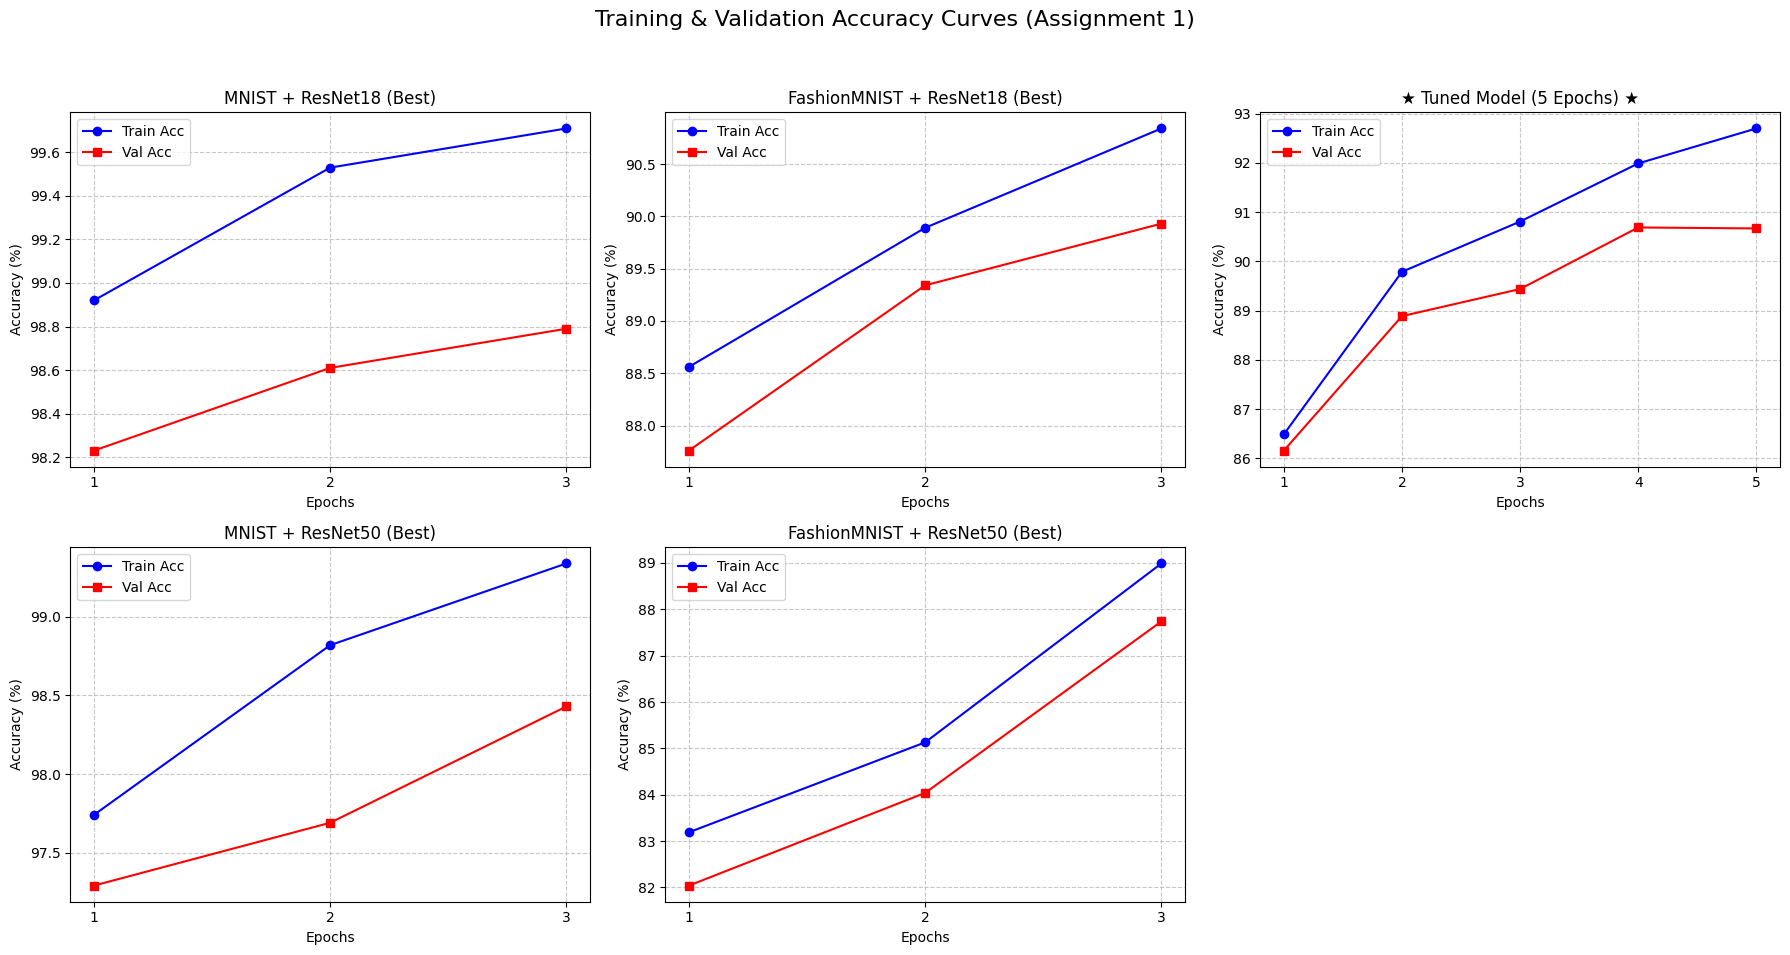

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- DATA EXTRACTED FROM YOUR LOGS ---

# 1. MNIST + ResNet18 (Best Config: SGD, BS=32, LR=0.001)
# Logs: Ep1: 98.23, Ep2: 98.61, Ep3: 98.79
m_r18_train = [98.92, 99.53, 99.71]
m_r18_val   = [98.23, 98.61, 98.79]

# 2. FashionMNIST + ResNet18 (Best Config: Adam, BS=32, LR=0.001)
# Logs: Ep1: 87.76, Ep2: 89.34, Ep3: 89.93
f_r18_train = [88.56, 89.89, 90.84]
f_r18_val   = [87.76, 89.34, 89.93]

# 3. MNIST + ResNet50 (Best Config: SGD, BS=32, LR=0.001)
# Logs: Ep1: 97.29, Ep2: 97.69, Ep3: 98.43
m_r50_train = [97.74, 98.82, 99.34]
m_r50_val   = [97.29, 97.69, 98.43]

# 4. FashionMNIST + ResNet50 (Best Config: SGD, BS=16, LR=0.001)
# Logs: Ep1: 82.04, Ep2: 84.04, Ep3: 87.74
f_r50_train = [83.19, 85.13, 88.99]
f_r50_val   = [82.04, 84.04, 87.74]

# 5. Hyperparameter Tuned (FashionMNIST + ResNet18 + 5 Epochs)
# Logs: Ep1: 86.16, Ep2: 88.89, Ep3: 89.44, Ep4: 90.69, Ep5: 90.67
tuned_train = [86.49, 89.79, 90.81, 91.99, 92.70]
tuned_val   = [86.16, 88.89, 89.44, 90.69, 90.67]

# --- PLOTTING ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training & Validation Accuracy Curves (Assignment 1)', fontsize=16)

# Helper function to plot
def plot_graph(ax, train, val, title, epochs=3):
    x_axis = range(1, epochs + 1)
    ax.plot(x_axis, train, 'b-o', label='Train Acc')
    ax.plot(x_axis, val, 'r-s', label='Val Acc')
    ax.set_title(title)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy (%)')
    ax.set_xticks(x_axis)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

# Plot 1: MNIST ResNet18
plot_graph(axes[0, 0], m_r18_train, m_r18_val, 'MNIST + ResNet18 (Best)')

# Plot 2: FashionMNIST ResNet18
plot_graph(axes[0, 1], f_r18_train, f_r18_val, 'FashionMNIST + ResNet18 (Best)')

# Plot 3: MNIST ResNet50
plot_graph(axes[1, 0], m_r50_train, m_r50_val, 'MNIST + ResNet50 (Best)')

# Plot 4: FashionMNIST ResNet50
plot_graph(axes[1, 1], f_r50_train, f_r50_val, 'FashionMNIST + ResNet50 (Best)')

# Plot 5: Tuned Model (Spanning 2 columns for emphasis)
# We hide the default 3rd subplot and make a new one or just use the last slot
plot_graph(axes[0, 2], tuned_train, tuned_val, '★ Tuned Model (5 Epochs) ★', epochs=5)

# Hide the empty 6th slot (bottom right)
axes[1, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.savefig('all_training_graphs.png', dpi=300)
print(" Graphs generated and saved to 'all_training_graphs.png'")
plt.show()

**Que-1(b) SVM Classifier with different kernels**

In [ ]:
kernels = ['rbf', 'poly']
datasets = ['MNIST', 'FashionMNIST']
svm_results = []

for d in datasets:
    for k in kernels:
        acc, t = run_svm(d, k)
        svm_results.append({'Dataset': d, 'Kernel': k, 'Accuracy': acc, 'Time_ms': t})

pd.DataFrame(svm_results).to_csv("results_svm.csv", index=False)

--- Preparing SVM Data for MNIST (70-10-20 Split) ---


100%|██████████| 9.91M/9.91M [00:00<00:00, 35.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.10MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.48MB/s]


   Extracting data to Numpy...
   Training SVM (Kernel='rbf')...
   Predicting...
   MNIST (rbf) Results -> Acc: 97.85% | Time: 163567 ms
--- Preparing SVM Data for MNIST (70-10-20 Split) ---
   Extracting data to Numpy...
   Training SVM (Kernel='poly')...
   Predicting...
   MNIST (poly) Results -> Acc: 98.25% | Time: 105367 ms
--- Preparing SVM Data for FashionMNIST (70-10-20 Split) ---
   Extracting data to Numpy...
   Training SVM (Kernel='rbf')...
   Predicting...
   FashionMNIST (rbf) Results -> Acc: 88.52% | Time: 236393 ms
--- Preparing SVM Data for FashionMNIST (70-10-20 Split) ---
   Extracting data to Numpy...
   Training SVM (Kernel='poly')...
   Predicting...
   FashionMNIST (poly) Results -> Acc: 89.34% | Time: 195064 ms


**Que-2 Running FashionMNIST on both CPU and GPU**

*Code for Resnet-18 and Resnet-50*

In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from thop import profile
import pandas as pd

# --- CONFIGURATION ---
EPOCHS = 2
dataset_name = 'FashionMNIST'
batch_size = 16
learning_rate = 0.001

# The full experiment list
experiments = [
    {'device': 'cpu', 'optim': 'SGD'},
    {'device': 'cpu', 'optim': 'Adam'},
    {'device': 'cuda', 'optim': 'SGD'},
    {'device': 'cuda', 'optim': 'Adam'}
]

model_names = ['resnet18', 'resnet50']
results = []

print(f"=== Starting Q2: FashionMNIST Table Generation (Epochs={EPOCHS}) ===")

# --- FIXED HELPER FUNCTION ---
def calculate_accuracy(model, loader, device):
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)

            # --- THE FIX: Move BOTH to CPU for comparison ---
            correct += (predicted.cpu() == labels.cpu()).sum().item()

    return 100 * correct / total

# --- MAIN LOOP ---
for exp in experiments:
    device_name = exp['device']
    optim_name = exp['optim']

    # Skip if GPU requested but not available
    if device_name == 'cuda' and not torch.cuda.is_available():
        print(f" Skipping GPU experiment ({optim_name}) - GPU not detected.")
        continue

    print(f"--- Running Row: Device={device_name.upper()} | Optim={optim_name} ---")

    row_data = {
        'Compute': device_name.upper(),
        'Batch Size': batch_size,
        'Optimizer': optim_name,
        'Learning Rate': learning_rate
    }

    for model_name in model_names:
        print(f"   ► Training {model_name}...", flush=True)

        # 1. Setup Model & Data
        # Pin memory helps GPU speed, but we turn it off for CPU to be safe
        pin = True if device_name == 'cuda' else False
        train_loader, val_loader, test_loader = get_dataloaders(dataset_name, batch_size, pin_memory=pin)

        model = get_model(model_name)
        device = torch.device(device_name)
        model = model.to(device)

        criterion = nn.CrossEntropyLoss()

        if optim_name == 'SGD':
            optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
        else:
            optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        # 2. Calculate FLOPs (Once per model/device combo)
        # We calculate it fresh every time to ensure the table row is complete
        dummy_input = torch.randn(1, 1, 32, 32).to(device)
        try:
            macs, _ = profile(model, inputs=(dummy_input, ), verbose=False)
            flops_g = macs / 1e9
        except:
            flops_g = 0.0

        # 3. Training Loop
        start_time = time.time()

        for epoch in range(EPOCHS):
            model.train()
            for images, labels in train_loader:
                images = images.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            # Epoch Monitoring
            train_acc = calculate_accuracy(model, train_loader, device)
            val_acc = calculate_accuracy(model, val_loader, device)
            print(f"      Ep {epoch+1}/{EPOCHS}: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

        if device_name == 'cuda': torch.cuda.synchronize()
        end_time = time.time()
        train_time_ms = (end_time - start_time) * 1000

        # 4. Final Test Accuracy
        test_acc = calculate_accuracy(model, test_loader, device)

        print(f"       Done. Test Acc: {test_acc:.2f}% | Total Time: {train_time_ms:.0f}ms")

        # Save Results
        row_data[f'{model_name} Acc (%)'] = test_acc
        row_data[f'{model_name} Time (ms)'] = train_time_ms
        row_data[f'{model_name} FLOPs (G)'] = flops_g

    results.append(row_data)

# --- Final Table Display ---
print("\n=== Final Q2 Results Table ===")
df_q2 = pd.DataFrame(results)

# Reorder columns to look exactly like the assignment table
cols = ['Compute', 'Batch Size', 'Optimizer', 'Learning Rate',
        'resnet18 Acc (%)', 'resnet50 Acc (%)',
        'resnet18 Time (ms)', 'resnet50 Time (ms)',
        'resnet18 FLOPs (G)', 'resnet50 FLOPs (G)']
df_q2 = df_q2[cols]

display(df_q2)
df_q2.to_csv("results_q2_table.csv", index=False)

=== Starting Q2: FashionMNIST Table Generation (Epochs=2) ===
--- Running Row: Device=CPU | Optim=SGD ---
   ► Training resnet18...
      Ep 1/2: Train Acc: 88.52% | Val Acc: 87.87%
      Ep 2/2: Train Acc: 90.01% | Val Acc: 88.47%
       Done. Test Acc: 88.20% | Total Time: 638716ms
   ► Training resnet50...
      Ep 1/2: Train Acc: 82.84% | Val Acc: 81.76%
      Ep 2/2: Train Acc: 86.31% | Val Acc: 85.59%
       Done. Test Acc: 85.19% | Total Time: 1800461ms
--- Running Row: Device=CPU | Optim=Adam ---
   ► Training resnet18...
      Ep 1/2: Train Acc: 87.24% | Val Acc: 86.49%
      Ep 2/2: Train Acc: 89.73% | Val Acc: 88.77%
       Done. Test Acc: 88.99% | Total Time: 855215ms
   ► Training resnet50...
      Ep 1/2: Train Acc: 83.61% | Val Acc: 83.03%
      Ep 2/2: Train Acc: 84.74% | Val Acc: 83.86%
       Done. Test Acc: 84.47% | Total Time: 2019986ms
--- Running Row: Device=CUDA | Optim=SGD ---
   ► Training resnet18...
      Ep 1/2: Train Acc: 88.00% | Val Acc: 86.30%
      Ep 2

,Compute,Batch Size,Optimizer,Learning Rate,resnet18 Acc (%),resnet50 Acc (%),resnet18 Time (ms),resnet50 Time (ms),resnet18 FLOPs (G),resnet50 FLOPs (G)
0,CPU,16,SGD,0.001,88.200000,85.185714,638715.842009,1.800461e+06,0.035615,0.082737
1,CPU,16,Adam,0.001,88.992857,84.471429,855215.271235,2.019986e+06,0.035615,0.082737
2,CUDA,16,SGD,0.001,88.835714,86.400000,123926.942110,2.141939e+05,0.035615,0.082737
3,CUDA,16,Adam,0.001,88.121429,80.614286,136046.204329,2.395487e+05,0.035615,0.082737


*Code for Resnet-32*

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Standard ResNet Basic Block ---
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

# --- ResNet-32 Main Architecture ---
class ResNet_Cifar(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet_Cifar, self).__init__()
        self.in_planes = 16

        # Initial Conv: 1 channel input (FashionMNIST) -> 16 channels
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        # 3 Stages of ResNet blocks
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)

        self.linear = nn.Linear(64, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

def ResNet32():
    # ResNet32 has 5 blocks per layer: (5*2)*3 + 2 = 32 layers
    return ResNet_Cifar(BasicBlock, [5, 5, 5])

**Resnet-32 and Combined results of Resnet-18, Resnet-32 and Resnet-50**

In [ ]:
import time
import pandas as pd
from thop import profile
import torch
import torch.nn as nn
import torch.optim as optim

# --- CONFIGURATION ---
EPOCHS = 2
dataset_name = 'FashionMNIST'
batch_size = 16
learning_rate = 0.001

r32_results = []

experiments = [
    {'device': 'cpu', 'optim': 'SGD'},
    {'device': 'cpu', 'optim': 'Adam'},
    {'device': 'cuda', 'optim': 'SGD'},
    {'device': 'cuda', 'optim': 'Adam'}
]

print(f"=== Starting Q2 Part B: ResNet-32 Only (Epochs={EPOCHS}) ===")
print(" Note: CPU runs will take time. Please be patient!\n")

# --- SAFE ACCURACY HELPER (Same as Q2) ---
def calculate_accuracy(model, loader, device):
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            # Safe comparison on CPU
            correct += (predicted.cpu() == labels.cpu()).sum().item()
    return 100 * correct / total

for exp in experiments:
    device_name = exp['device']
    optim_name = exp['optim']

    # Skip GPU if not available
    if device_name == 'cuda' and not torch.cuda.is_available():
        continue

    print(f"--- Running ResNet-32: Device={device_name.upper()} | Optim={optim_name} ---")

    # 1. Setup Data & Model
    pin = True if device_name == 'cuda' else False
    train_loader, val_loader, test_loader = get_dataloaders(dataset_name, batch_size, pin_memory=pin)

    # Initialize Custom ResNet32
    model = ResNet32() # Ensure the class ResNet32 is defined in a previous cell!
    device = torch.device(device_name)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    if optim_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # 2. FLOPs
    dummy_input = torch.randn(1, 1, 32, 32).to(device)
    try:
        macs, _ = profile(model, inputs=(dummy_input, ), verbose=False)
        flops_g = macs / 1e9
    except:
        flops_g = 0.0

    # 3. Training Loop
    start_time = time.time()
    for epoch in range(EPOCHS):
        model.train()
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # --- IMPROVED LOGGING (Train & Val) ---
        train_acc = calculate_accuracy(model, train_loader, device)
        val_acc = calculate_accuracy(model, val_loader, device)
        print(f"      Ep {epoch+1}/{EPOCHS}: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if device_name == 'cuda': torch.cuda.synchronize()
    end_time = time.time()
    train_time_ms = (end_time - start_time) * 1000

    # 4. Final Test Accuracy
    test_acc = calculate_accuracy(model, test_loader, device)
    print(f"       Done. Test Acc: {test_acc:.2f}% | Time: {train_time_ms:.0f}ms")

    # Save formatted result
    r32_results.append({
        'Compute': device_name.upper(),
        'Optimizer': optim_name,
        'resnet32 Acc (%)': test_acc,
        'resnet32 Time (ms)': train_time_ms,
        'resnet32 FLOPs (G)': flops_g
    })

# --- MERGE WITH EXISTING TABLE ---
print("\n=== Merging with Previous Q2 Results ===")

# Load your existing table (ResNet18 & 50)
try:
    df_main = pd.read_csv("results_q2_table.csv")
    df_r32 = pd.DataFrame(r32_results)

    # Merge on Compute/Optimizer
    df_final = pd.merge(df_main, df_r32, on=['Compute', 'Optimizer'], how='left')

    # Reorder columns
    final_cols = [
        'Compute', 'Batch Size', 'Optimizer', 'Learning Rate',
        'resnet18 Acc (%)', 'resnet32 Acc (%)', 'resnet50 Acc (%)',
        'resnet18 Time (ms)', 'resnet32 Time (ms)', 'resnet50 Time (ms)',
        'resnet18 FLOPs (G)', 'resnet32 FLOPs (G)', 'resnet50 FLOPs (G)'
    ]
    df_final = df_final[final_cols]

    display(df_final)
    df_final.to_csv("results_q2_full_complete.csv", index=False)
    print(" Saved merged results to 'results_q2_full_complete.csv'")

except FileNotFoundError:
    print(" Could not find 'results_q2_table.csv'. Showing ResNet-32 results only:")
    display(pd.DataFrame(r32_results))

=== Starting Q2 Part B: ResNet-32 Only (Epochs=2) ===
 Note: CPU runs will take time. Please be patient!

--- Running ResNet-32: Device=CPU | Optim=SGD ---
      Ep 1/2: Train Acc: 88.70% | Val Acc: 88.76%
      Ep 2/2: Train Acc: 90.75% | Val Acc: 89.99%
       Done. Test Acc: 89.26% | Time: 741593ms
--- Running ResNet-32: Device=CPU | Optim=Adam ---
      Ep 1/2: Train Acc: 87.27% | Val Acc: 86.44%
      Ep 2/2: Train Acc: 89.78% | Val Acc: 89.04%
       Done. Test Acc: 89.21% | Time: 744994ms
--- Running ResNet-32: Device=CUDA | Optim=SGD ---
      Ep 1/2: Train Acc: 89.93% | Val Acc: 89.30%
      Ep 2/2: Train Acc: 90.97% | Val Acc: 90.16%
       Done. Test Acc: 90.25% | Time: 149280ms
--- Running ResNet-32: Device=CUDA | Optim=Adam ---
      Ep 1/2: Train Acc: 88.31% | Val Acc: 88.14%
      Ep 2/2: Train Acc: 90.30% | Val Acc: 89.90%
       Done. Test Acc: 89.65% | Time: 153516ms

=== Merging with Previous Q2 Results ===


,Compute,Batch Size,Optimizer,Learning Rate,resnet18 Acc (%),resnet32 Acc (%),resnet50 Acc (%),resnet18 Time (ms),resnet32 Time (ms),resnet50 Time (ms),resnet18 FLOPs (G),resnet32 FLOPs (G),resnet50 FLOPs (G)
0,CPU,16,SGD,0.001,88.200000,89.257143,85.185714,638715.842009,741592.550039,1.800461e+06,0.035615,0.070091,0.082737
1,CPU,16,Adam,0.001,88.992857,89.214286,84.471429,855215.271235,744993.685246,2.019986e+06,0.035615,0.070091,0.082737
2,CUDA,16,SGD,0.001,88.835714,90.250000,86.400000,123926.942110,149279.853106,2.141939e+05,0.035615,0.070091,0.082737
3,CUDA,16,Adam,0.001,88.121429,89.650000,80.614286,136046.204329,153515.823126,2.395487e+05,0.035615,0.070091,0.082737


 Saved merged results to 'results_q2_full_complete.csv'


**Speedup graph**

Q2 Graph Saved: q2_speedup_graph.png


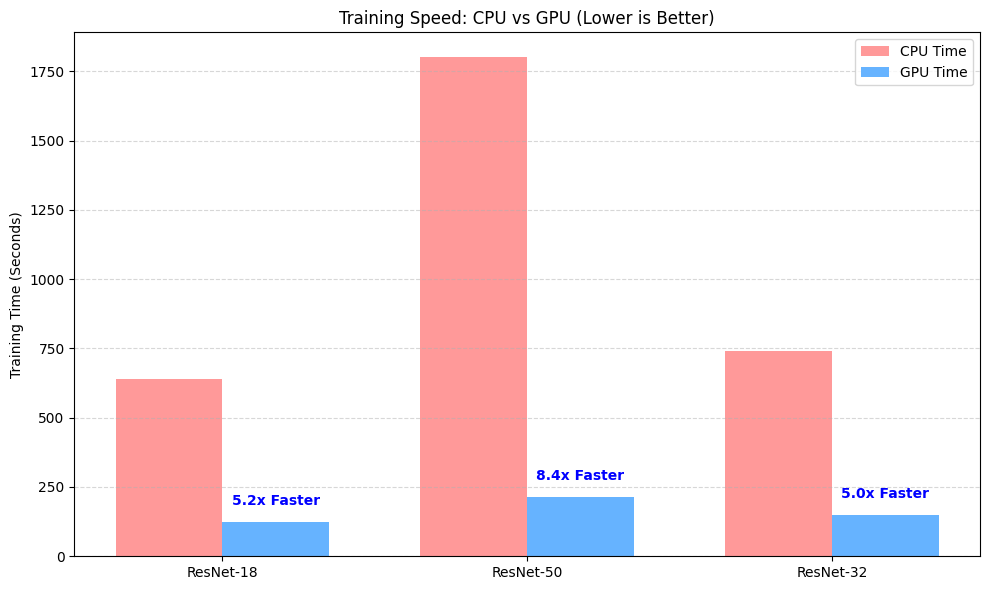

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load your final data
df = pd.read_csv("results_q2_full_complete.csv")

# Filter for the specific optimizer comparison (e.g., SGD, since it's standard)
subset = df[df['Optimizer'] == 'SGD']

# Data Prep
models = ['ResNet-18', 'ResNet-50', 'ResNet-32']
cpu_times = []
gpu_times = []

for model in ['resnet18', 'resnet50', 'resnet32']:
    # Get CPU time (convert ms to seconds for readability)
    t_cpu = subset[subset['Compute'] == 'CPU'][f'{model} Time (ms)'].values[0] / 1000
    cpu_times.append(t_cpu)

    # Get GPU time
    t_gpu = subset[subset['Compute'] == 'CUDA'][f'{model} Time (ms)'].values[0] / 1000
    gpu_times.append(t_gpu)

# Plotting
x = np.arange(len(models))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

# Create Bars
rects1 = ax1.bar(x - width/2, cpu_times, width, label='CPU Time', color='#ff9999')
rects2 = ax1.bar(x + width/2, gpu_times, width, label='GPU Time', color='#66b3ff')

# Formatting
ax1.set_ylabel('Training Time (Seconds)')
ax1.set_title('Training Speed: CPU vs GPU (Lower is Better)')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Add speedup text on top of GPU bars
for i in range(len(models)):
    speedup = cpu_times[i] / gpu_times[i]
    ax1.text(x[i] + width/2, gpu_times[i] + 50, f'{speedup:.1f}x Faster',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='blue')

plt.tight_layout()
plt.savefig('q2_speedup_graph.png')
print("Q2 Graph Saved: q2_speedup_graph.png")
plt.show()

**Commit to Github**

In [ ]:
import os
import shutil
import glob

# --- CONFIGURATION ---
REPO_DIR = "MLOps-Jyoti-Dwivedi-M25CSA010"  # Your repo folder
BRANCH_NAME = "Assignment-1"

# 1. Define the COMPLETE list of files you want to keep
# I have added everything from your list except the 'data' folder (which is too big/unnecessary)
all_files = [
    # The Best Tuned Model (Critical)
    "hyperparameter_tuned_model.pth",

    # The Q1(a) Checkpoints (Good evidence)
    "best_model_FashionMNIST_resnet18.pth",
    "best_model_FashionMNIST_resnet50.pth",
    "best_model_MNIST_resnet18.pth",
    "best_model_MNIST_resnet50.pth",

    # The Q1(a) Log CSVs (Shows your epoch-by-epoch progress)
    "results_fashion_res18.csv",
    "results_fashion_res50.csv",
    "results_mnist_res18.csv",
    "results_mnist_res50.csv",

    # The Q1(b) SVM Results
    "results_svm.csv",

    # The Q2 Benchmarking Results (Full version)
    "results_q2_full_complete.csv",

    # The Visuals (Graphs)
    "all_training_graphs.png",
    "q2_speedup_graph.png"
]

print(f" Moving {len(all_files)} files into {REPO_DIR}...")

for file_name in all_files:
    # We use explicit file names to avoid moving the '.git' folder or 'data' folder
    if os.path.exists(file_name):
        try:
            shutil.copy(file_name, f"{REPO_DIR}/{file_name}")
            print(f"   Moved: {file_name}")
        except Exception as e:
            print(f"    Error moving {file_name}: {e}")
    else:
        print(f"   File not found (skipped): {file_name}")

# 2. Change Directory INTO the Repo
os.chdir(REPO_DIR)
print(f"\n Current Directory: {os.getcwd()}")

# 3. Wake up Git
!git config --global user.email "m25csa010@iitj.ac.in"
!git config --global user.name "Jyoti Dwivedi"

# 4. Add, Commit, Push EVERYTHING
print("\n Pushing all files to GitHub...")
!git add *.csv *.png *.pth
!git commit -m "Full Submission: Included all experiment logs, best models, and Q2 speedup graphs"
!git push origin {BRANCH_NAME}

 Moving 13 files into MLOps-Jyoti-Dwivedi-M25CSA010...
   File not found (skipped): hyperparameter_tuned_model.pth
   File not found (skipped): best_model_FashionMNIST_resnet18.pth
   File not found (skipped): best_model_FashionMNIST_resnet50.pth
   File not found (skipped): best_model_MNIST_resnet18.pth
   File not found (skipped): best_model_MNIST_resnet50.pth
   File not found (skipped): results_fashion_res18.csv
   File not found (skipped): results_fashion_res50.csv
   File not found (skipped): results_mnist_res18.csv
   File not found (skipped): results_mnist_res50.csv
   Moved: results_svm.csv
   Moved: results_q2_full_complete.csv
   Moved: all_training_graphs.png
   Moved: q2_speedup_graph.png

 Current Directory: /kaggle/working/MLOps-Jyoti-Dwivedi-M25CSA010

 Pushing all files to GitHub...
[Assignment-1 6e34784] Full Submission: Included all experiment logs, best models, and Q2 speedup graphs
 13 files changed, 46 insertions(+)
 create mode 100644 all_training_graphs.png
 cre